Q1. What is the total volume of power of purchased by the trader? 

In [2]:
# inputs
quantity_lots=1
lot_size_hour=1
baseload_hours=24
number_of_days_2027=365
volume=quantity_lots*lot_size_hour*baseload_hours*number_of_days_2027
print(f'{volume} MWh')

8760 MWh


Q2. On 4-Apr-25, what is the (mark to market) value of this trade?


In [28]:
settlement_price={'4-Apr-25':89.91}
MTM_4_Apr_2025=settlement_price['4-Apr-25']*volume
#MTM_4_Apr_2025
print(f'€{MTM_4_Apr_2025}')

€787611.6


Q3. Next day, on 5-Apr-25, assume the closing price = 85, answer the following:

a.Has the trader made or lost money on this trade? 

Ans: The trader has lost money, the price dropped from 89.91 to 85

b.Is the profit or loss realized or unrealized? Explain in terms of “variation margin” as this is an exchange trade. 

Ans: The loss is unrealised as the position is open

c.What is the MTM of the trade on 5-Apr-25 ?

d. PNL dtd (profit or loss – day to day) on this trade on 5-Apr-25 ?


In [29]:
#
settlement_price['5-Apr-25']= 85
MTM_5_Apr_2025=settlement_price['5-Apr-25']*volume
print(f'MTM_5_Apr_2025 : €{MTM_5_Apr_2025}')

#d 
PNL_5_Apr_25=(settlement_price['5-Apr-25']-settlement_price['4-Apr-25'])*volume
print(f'PNL_5_Apr_25 :€{PNL_5_Apr_25:.2f} ')


MTM_5_Apr_2025 : €744600
PNL_5_Apr_25 :€-43011.60 


Q4. On 6-April-25 - Say we predict that there will be another global tariff and we think this will shoot up prices for power by 10%. What will be the impact on our trade on 6-Apr-25 if the price went up by 10% from the previous day? (i.e. from 5-Apr-25). Can you calculate the following:

a.MTM of the trade on 6-Apr-25

b.PNL dtd (profit or loss – day to day) on this trade on 6-Apr-25


In [33]:
settlement_price['6-Apr-25'] = round(settlement_price['5-Apr-25'] * 1.1, 2)
MTM_6_Apr_2025=settlement_price['6-Apr-25']*volume
print(f'MTM_6_Apr_2025 : {MTM_6_Apr_2025:.2f} Euros')

#PNL dtd
PNL_6_Apr_25=(settlement_price['6-Apr-25']-settlement_price['5-Apr-25'])*volume
print(f'PNL_6_Apr_25 :{PNL_6_Apr_25:.2f} Euros')

MTM_6_Apr_2025 : 819060.00 Euros
PNL_6_Apr_25 :74460.00 Euros


Q5. Based on the above trade specs, write a simply python program which will ask the user to enter a closing date:4-Apr-25 OR 5-APR-25 OR 6-APR-25

And based on the scenario above and chosen date, return the following results:

MTM = _______
PNL = ______

In [ ]:
def calculate_mtm_and_pnl(date):
    volume = 8760  # volume=quantity_lots*lot_size_hour*baseload_hours*number_of_days_2027
    
    # Settlement prices per day
    prices = {
        '4-Apr-25': 89.91,
        '5-Apr-25': 85.00,    # assumed
        '6-Apr-25': 93.50     # 10% increase from 85
    }

    if date not in prices:
        return "Invalid date. Choose from: 4-Apr-25, 5-Apr-25, 6-Apr-25"

    # Current day's price
    price_today = prices[date]
    
    # Calculate MTM
    mtm_today = price_today * volume

    # Calculate PNL DTD
    dates = ['4-Apr-25', '5-Apr-25', '6-Apr-25']
    idx = dates.index(date)

    if idx == 0:
        pnl_dtd = 0  # No prior day
    else:
        price_yesterday = prices[dates[idx - 1]]
        pnl_dtd = (price_today - price_yesterday) * volume

    return f"MTM = €{mtm_today:,.2f}\nPNL = €{pnl_dtd:,.2f}"




In [39]:
user_input = input("Enter a date (4-Apr-25, 5-Apr-25, 6-Apr-25): ")
print(calculate_mtm_and_pnl(user_input))

MTM = €819,060.00
PNL = €74,460.00


In [34]:
settlement_price

{'4-Apr-25': 89.91, '5-Apr-25': 85, '6-Apr-25': 93.5}

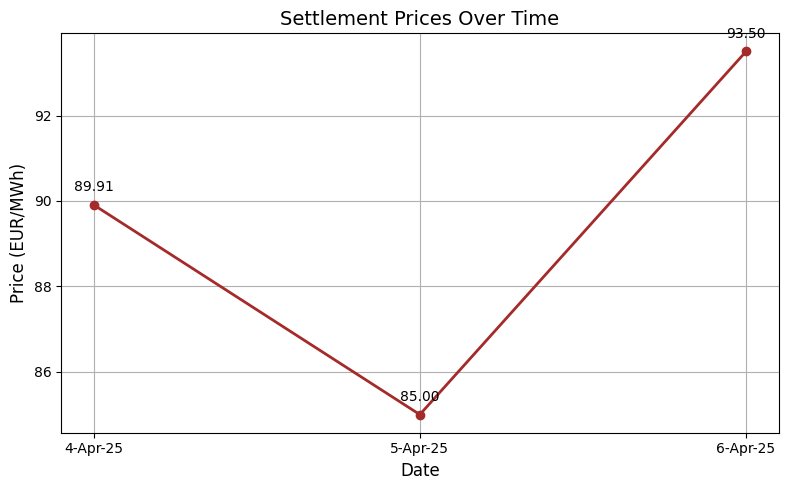

In [36]:
import matplotlib.pyplot as plt

# Extract dates and prices
dates = list(settlement_price.keys())
prices = list(settlement_price.values())

# Plot
plt.figure(figsize=(8, 5))
plt.plot(dates, prices, marker='o', linestyle='-', color='brown', linewidth=2)

# Add titles and labels
plt.title('Settlement Prices Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (EUR/MWh)', fontsize=12)
plt.grid(True)

# Annotate each point with its value
for i, txt in enumerate(prices):
    plt.annotate(f"{txt:.2f}", (dates[i], prices[i]), textcoords="offset points", xytext=(0, 10), ha='center')

plt.tight_layout()
plt.show()